# Model Comparison

Three machine learning algorithms were evaluated:

- Random Forest
- Support Vector Machine (SVM)
- XGBoost

Their accuracies were compared to select the best model.

In [11]:
import pandas as pd

df = pd.read_csv(
    "../dataset/final_selected_dataset.csv"
)

df.head()

,ILMN_1700461,ILMN_1776119,ILMN_1658083,ILMN_1738921,ILMN_2225595,ILMN_2352009,ILMN_1679600,ILMN_1691714,ILMN_1663132,ILMN_1700349,...,ILMN_1672940,ILMN_2078141,ILMN_1654612,ILMN_1698048,ILMN_2171640,ILMN_1670640,ILMN_2045175,ILMN_1800750,ILMN_2175447,Label
0,935.6070,234.3474,118.2800,893.8805,592.6266,374.2499,185.0592,163.18570,1589.801,103.54250,...,333.9715,458.4577,836.6818,201.1774,221.9025,111.72160,198.4151,712.3456,1163.6610,0
1,977.2614,145.9691,109.0556,644.9527,570.0883,507.2513,358.0979,198.91040,2594.574,134.12930,...,228.6719,377.9895,1905.3080,170.5912,173.0880,97.06413,188.7685,1317.0420,2195.4550,0
2,983.6641,257.5760,106.1608,712.3958,618.5681,395.5662,180.6711,64.65596,1119.165,74.19514,...,184.3754,272.9053,1132.6740,123.8508,152.4242,83.12721,193.6905,621.4002,1192.7820,0
3,1600.8570,307.8341,130.4562,1260.5380,797.9879,755.7017,328.9742,187.57900,3637.393,132.63230,...,310.4337,518.6738,1297.1330,175.4108,210.0579,121.11830,334.0703,2405.5520,1790.9140,0
4,1412.7820,400.2456,131.5690,755.1400,505.1268,655.3365,347.9955,191.31880,1811.977,73.71181,...,505.9775,296.5089,892.4323,126.5319,174.2380,83.72725,210.2115,1444.1460,989.1553,0


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(
    "Label",
    axis=1
)

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest:",
    round(rf_acc * 100, 2)
)

Random Forest: 81.25


In [14]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(
    X_train,
    y_train
)

svm_pred = svm.predict(
    X_test
)

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM:",
    round(svm_acc * 100, 2)
)

SVM: 81.25


In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost:",
    round(xgb_acc * 100, 2)
)

XGBoost: 81.25


In [16]:
comparison = pd.DataFrame(
    {
        "Model":[
            "Random Forest",
            "SVM",
            "XGBoost"
        ],
        "Accuracy":[
            rf_acc*100,
            svm_acc*100,
            xgb_acc*100
        ]
    }
)

comparison

,Model,Accuracy
0,Random Forest,81.25
1,SVM,81.25
2,XGBoost,81.25


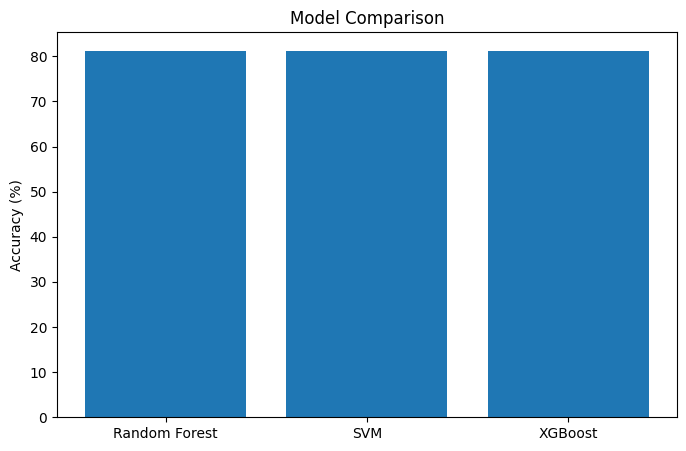

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Model Comparison"
)

plt.show()

In [18]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(
    "Best Model:"
)

print(best_model)

Best Model:
Model       Random Forest
Accuracy            81.25
Name: 0, dtype: object


## Conclusion

Three machine learning models were evaluated.

Random Forest achieved an accuracy of 81.25%.

Due to its performance and interpretability,
Random Forest was selected as the final model
for deployment in the OralGuard AI system.